In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv("heart_statlog_cleveland_hungary_final.csv")
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [3]:
df.dropna(inplace=True)
print("Nulls have been dropped")
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")
df.drop_duplicates(inplace=True)
print("Duplicates have been dropped")

Nulls have been dropped
Number of duplicate rows: 272
Duplicates have been dropped


Class distribution (counts):
 target
1    508
0    410
Name: count, dtype: int64

Class distribution (percentages):
 target
1    55.34
0    44.66
Name: proportion, dtype: float64


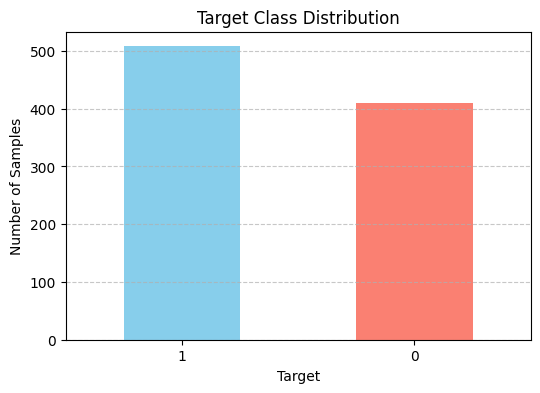

In [4]:
class_counts = df['target'].value_counts()
class_percentages = df['target'].value_counts(normalize=True) * 100

# numerical summary
print("Class distribution (counts):\n", class_counts)
print("\nClass distribution (percentages):\n", class_percentages.round(2))

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Target Class Distribution')
plt.xlabel('Target')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [5]:
X = df.drop('target', axis=1)
y = df['target']
adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X, y)
df_adasyn = pd.DataFrame(X_resampled, columns=X.columns)
df_adasyn['target'] = y_resampled

# Shuffle the data
df_adasyn = df_adasyn.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_adasyn.head())
print(df_adasyn['target'].value_counts())

   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   74    1                3           140          237                    1   
1   73    1                3           138            0                    0   
2   43    1                4           150          247                    0   
3   65    1                4           170          263                    1   
4   48    0                4           150          227                    0   

   resting ecg  max heart rate  exercise angina   oldpeak  ST slope  target  
0            0              94                0  0.000000         2       1  
1            0             116                0  0.196807         1       0  
2            0             130                1  2.000000         2       1  
3            0             112                1  2.000000         2       1  
4            0             130                1  1.000000         2       0  
target
1    508
0    439
Name: count, dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  918 non-null    int64  
 1   sex                  918 non-null    int64  
 2   chest pain type      918 non-null    int64  
 3   resting bp s         918 non-null    int64  
 4   cholesterol          918 non-null    int64  
 5   fasting blood sugar  918 non-null    int64  
 6   resting ecg          918 non-null    int64  
 7   max heart rate       918 non-null    int64  
 8   exercise angina      918 non-null    int64  
 9   oldpeak              918 non-null    float64
 10  ST slope             918 non-null    int64  
 11  target               918 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 93.2 KB


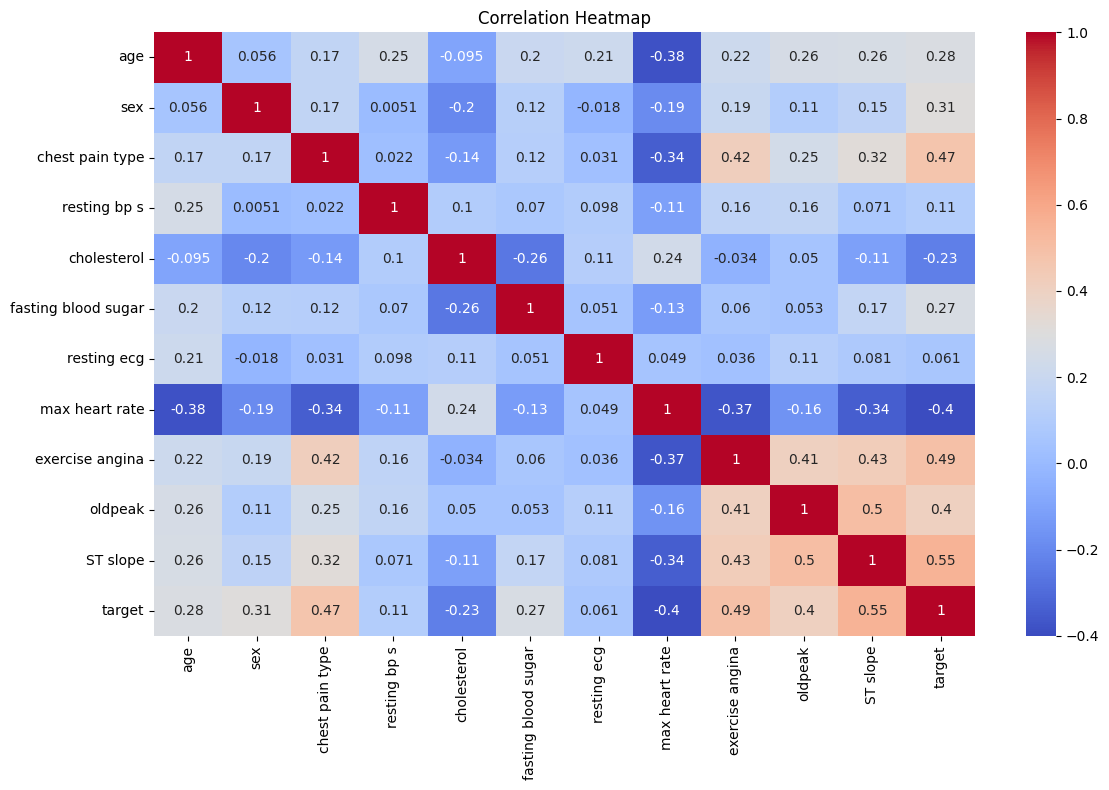

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Feature Engineering based on scientific knowledge we found online**

In [8]:
df['bp_cp_interaction'] = df['resting bp s'] * df['chest pain type']
df['angina_cp_interaction'] = df['exercise angina'] * df['chest pain type']
df['angina_hr_product'] = df['exercise angina'] * df['max heart rate']

# and lets drop the low correlations
df.drop(columns=['max heart rate', 'resting ecg', 'cholesterol', 'resting bp s'], inplace=True)


# and some names are giving us a hard time so lets rename them
df.rename(columns={
    'chest pain type': 'cp',
    'resting bp s': 'trestbps',
    'cholesterol': 'chol',
    'fasting blood sugar': 'fbs',
    'resting ecg': 'restecg',
    'max heart rate': 'thalach',
    'exercise angina': 'exang',
    'ST slope': 'slope'
}, inplace=True)

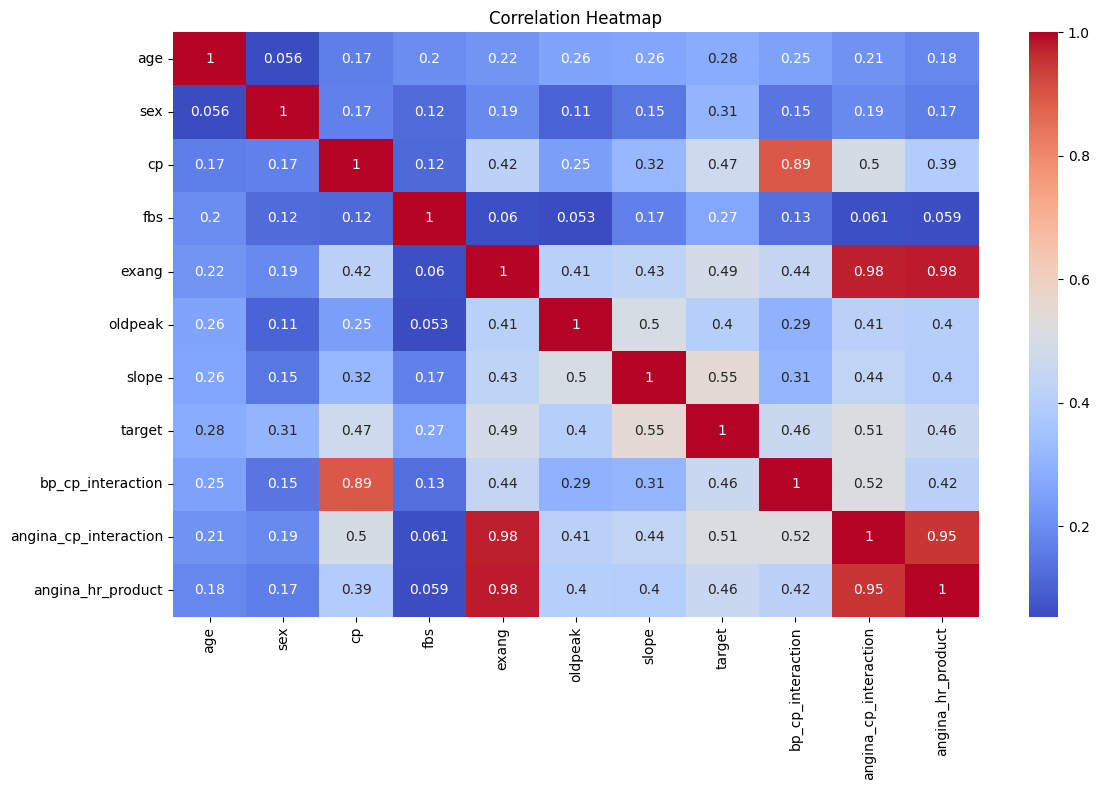

In [9]:
# new correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Now lets look at the distribution of the numeric features**

<ipython-input-10-57842faa19ca>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


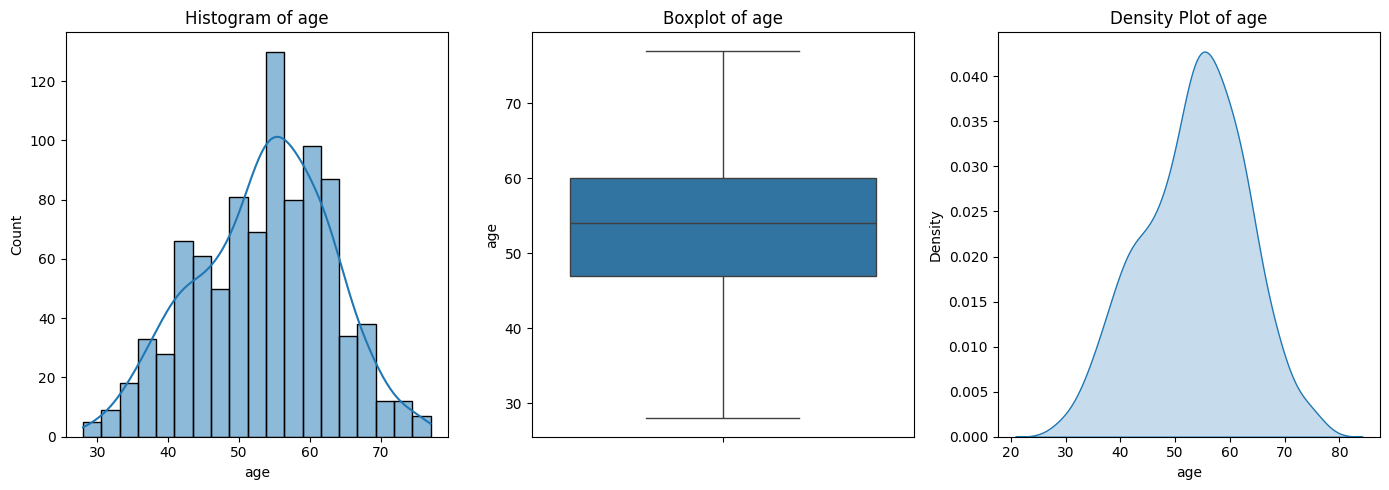

<ipython-input-10-57842faa19ca>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


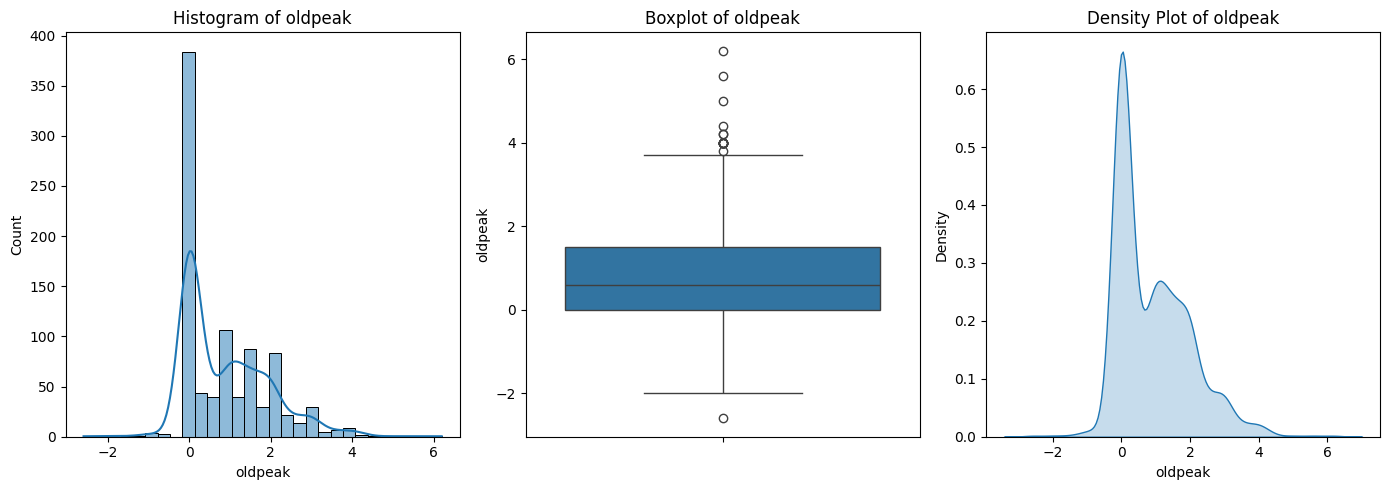

<ipython-input-10-57842faa19ca>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


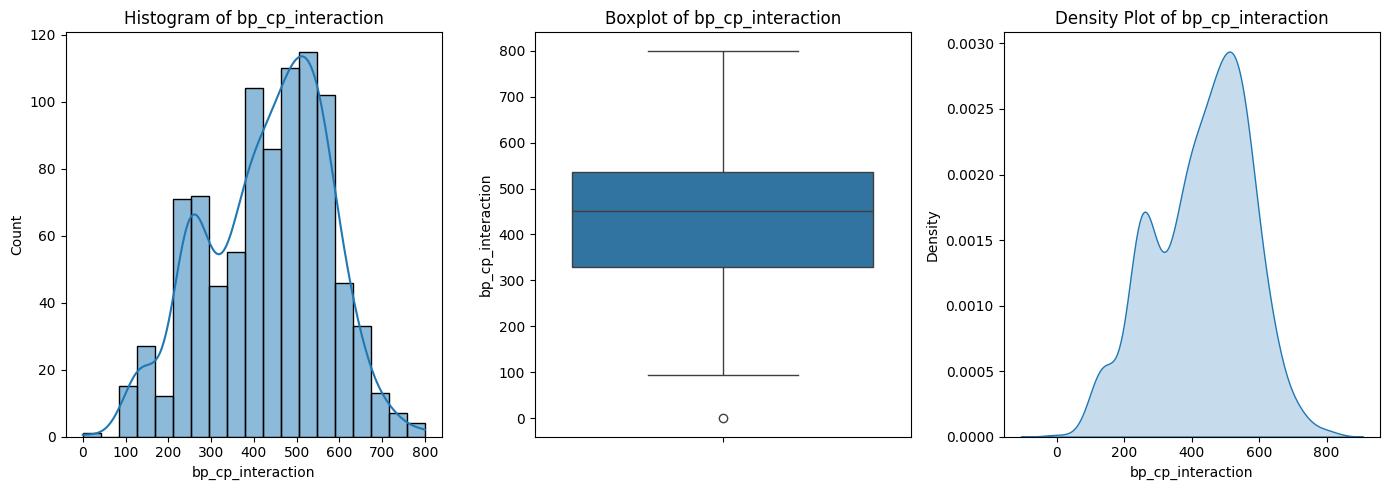

<ipython-input-10-57842faa19ca>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


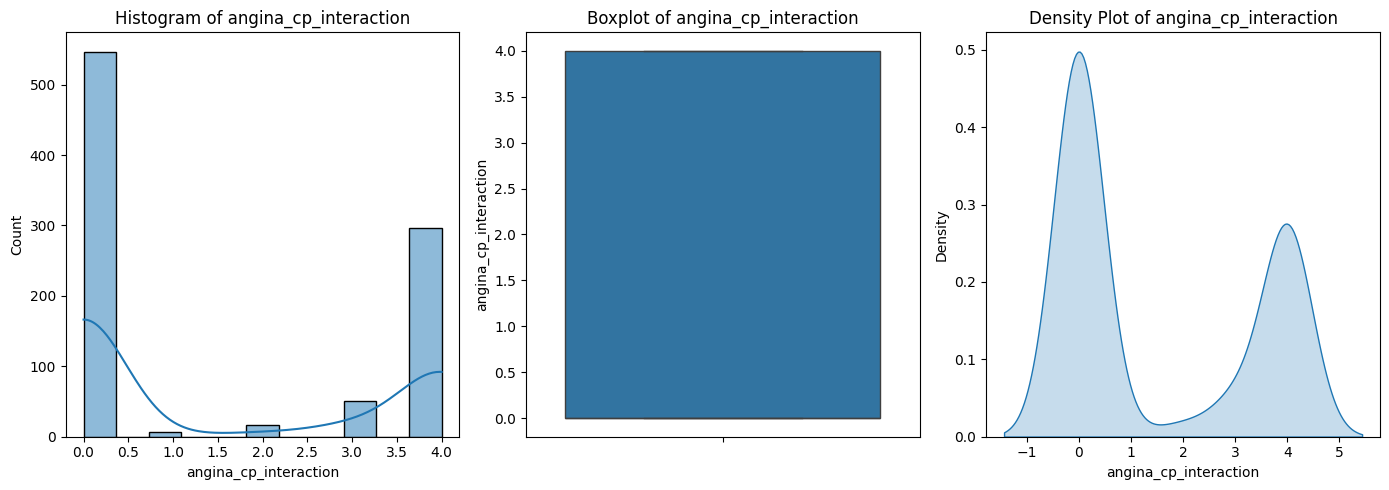

<ipython-input-10-57842faa19ca>:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True)


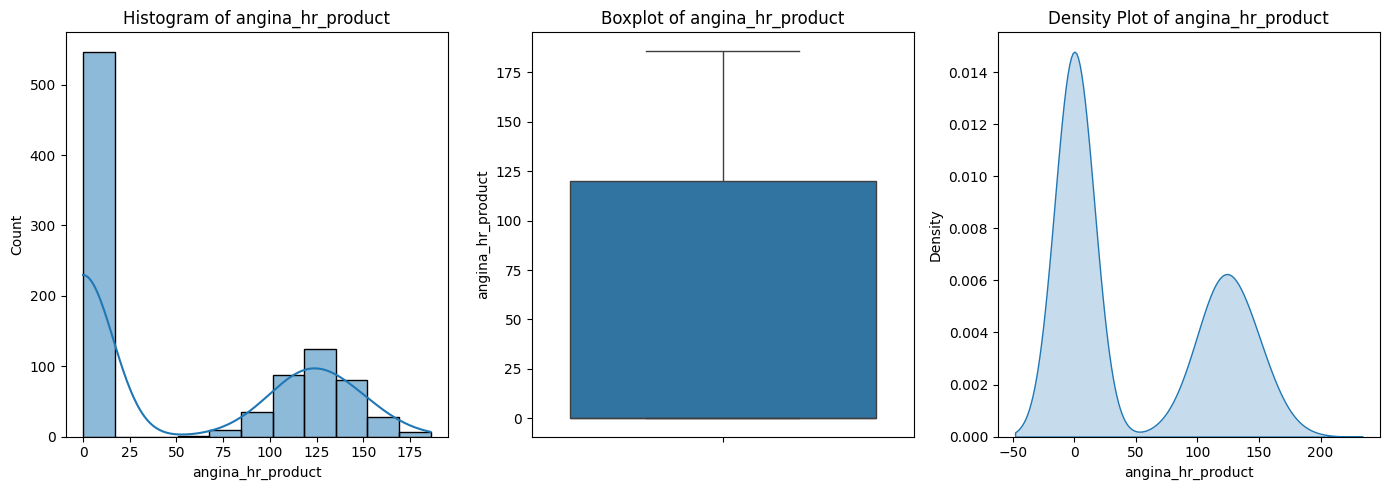

In [10]:
numeric_cols = ['age', 'oldpeak', 'bp_cp_interaction', 'angina_cp_interaction', 'angina_hr_product']

# Histograms and Boxplots
for col in numeric_cols:
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

    plt.subplot(1, 3, 3)
    sns.kdeplot(df[col], shade=True)
    plt.title(f'Density Plot of {col}')

    plt.tight_layout()
    plt.show()

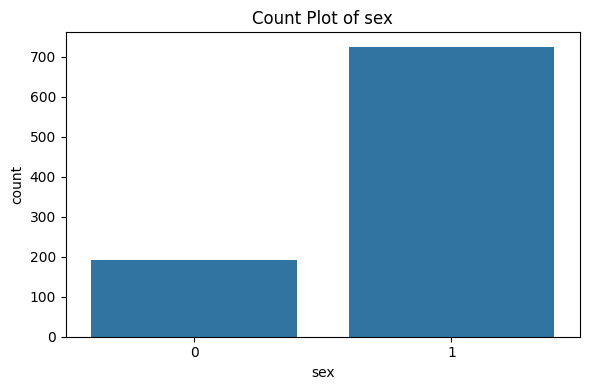

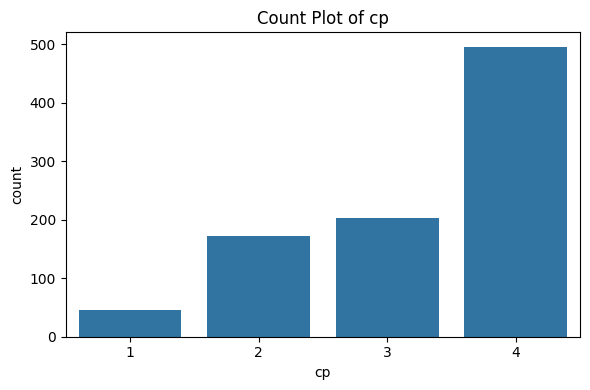

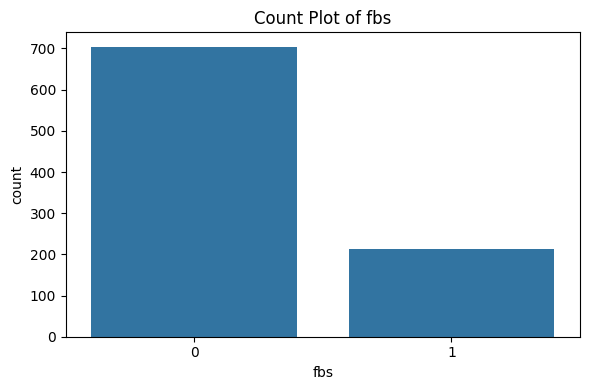

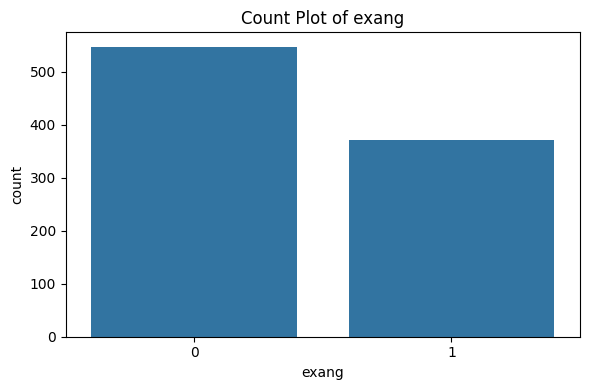

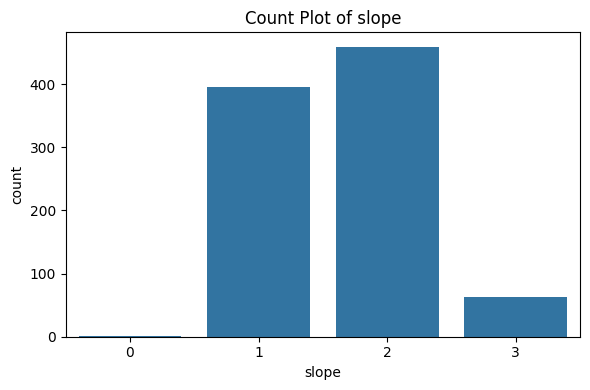

In [11]:
# also lets take a look at the categorical features distribution
categorical_cols = ['sex', 'cp', 'fbs', 'exang', 'slope']

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Count Plot of {col}')
    plt.tight_layout()
    plt.show()

In [12]:
# what we can fix so far in the data is outliers, but since the data is already small we will change the outlier values to the mean of the data column instead
def replace_outliers_with_median(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    median = column.median()
    return column.apply(lambda x: median if x < lower or x > upper else x)


for col in numeric_cols:
    df[col] = replace_outliers_with_median(df[col])

print(df[numeric_cols].describe())

              age     oldpeak  bp_cp_interaction  angina_cp_interaction  \
count  918.000000  918.000000         918.000000             918.000000   
mean    53.510893    0.829412         431.376906               1.504357   
std      9.432617    0.958009         139.598191               1.870241   
min     28.000000   -2.000000          95.000000               0.000000   
25%     47.000000    0.000000         330.000000               0.000000   
50%     54.000000    0.600000         450.000000               0.000000   
75%     60.000000    1.500000         536.000000               4.000000   
max     77.000000    3.700000         800.000000               4.000000   

       angina_hr_product  
count         918.000000  
mean           50.664488  
std            62.908587  
min             0.000000  
25%             0.000000  
50%             0.000000  
75%           120.000000  
max           186.000000  


<ipython-input-13-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


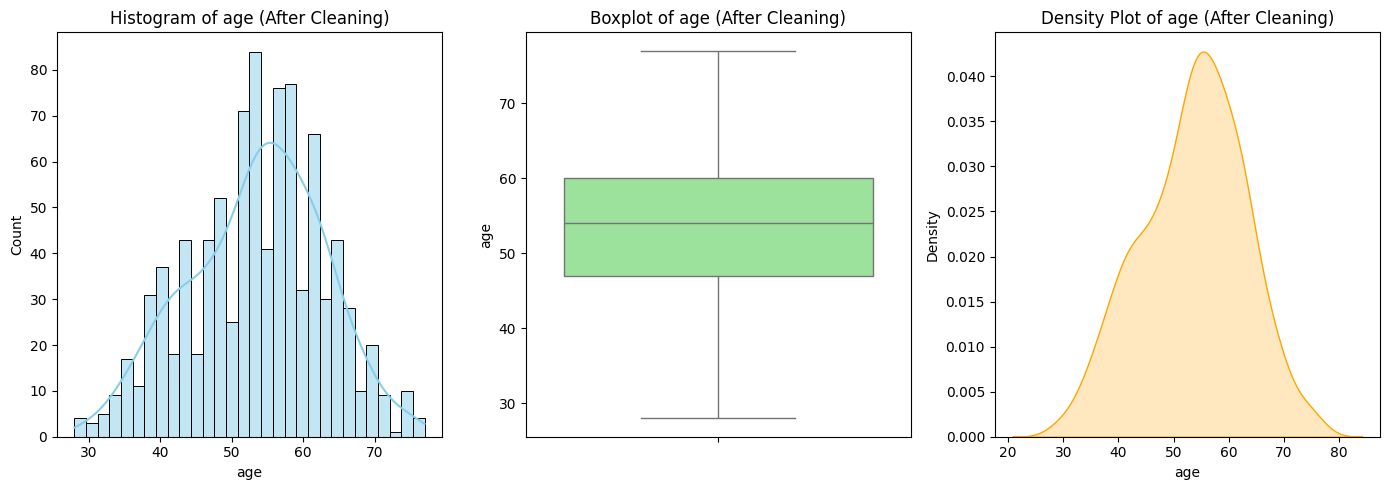

<ipython-input-13-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


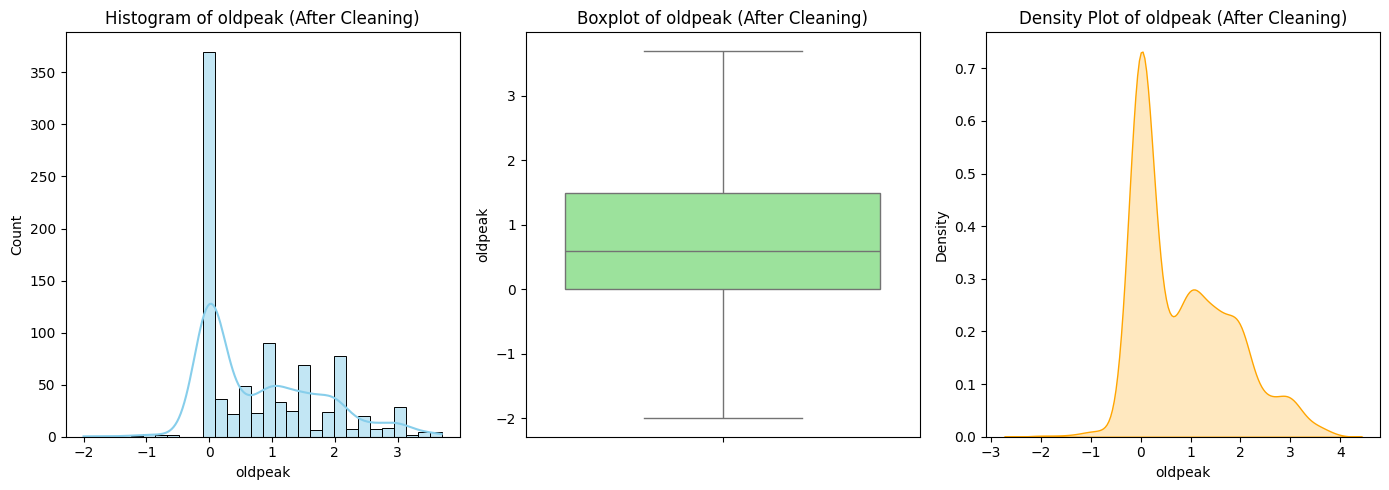

<ipython-input-13-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


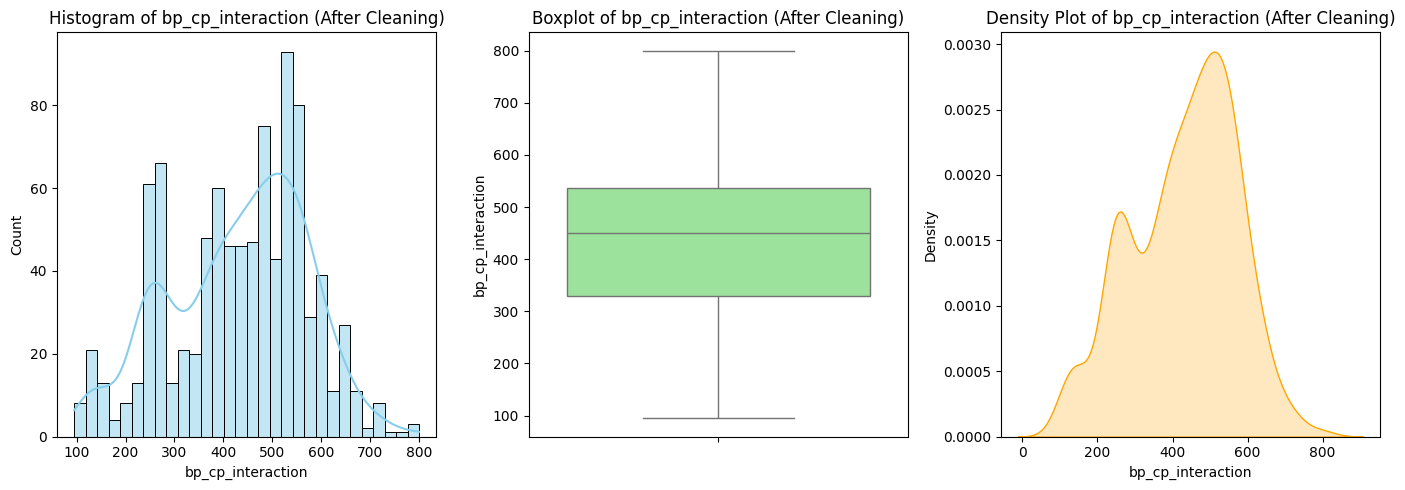

<ipython-input-13-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


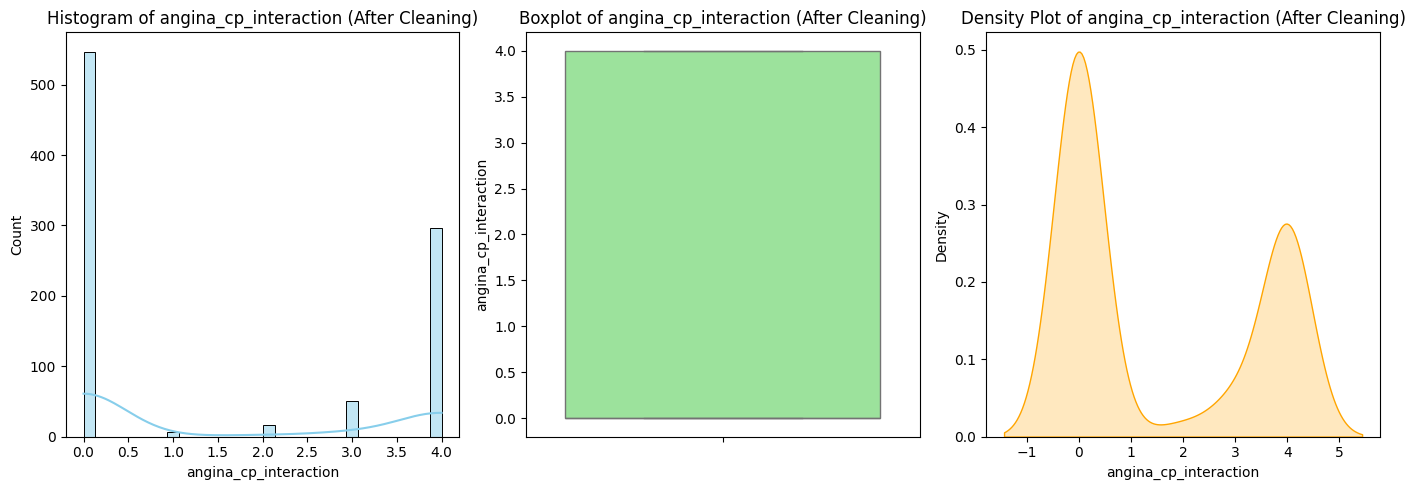

<ipython-input-13-fd418c611d76>:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[col], shade=True, color='orange')


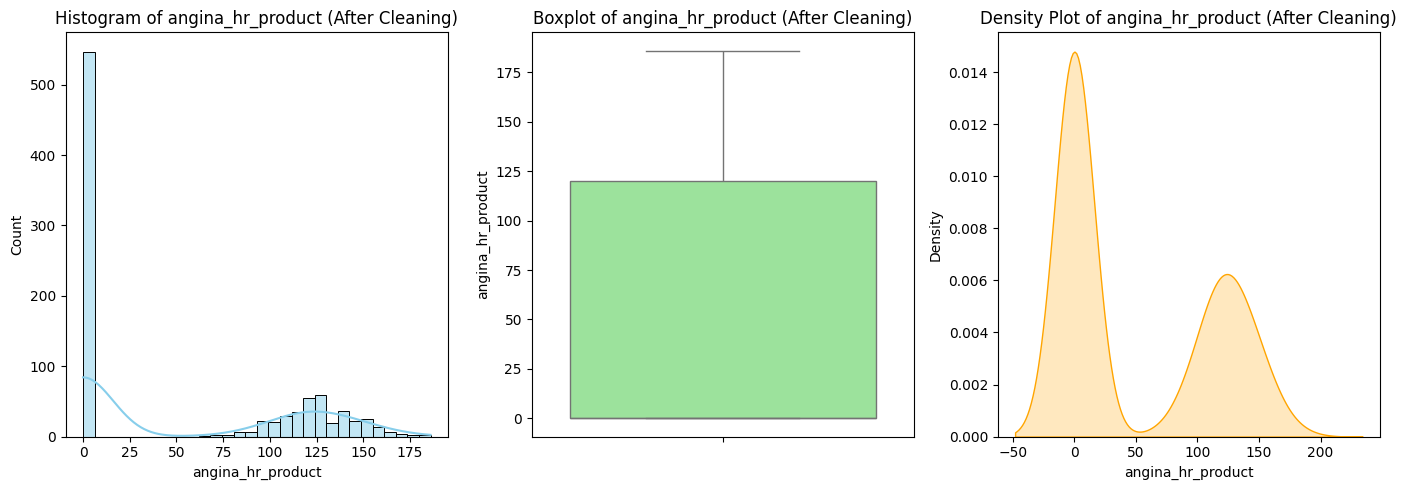

In [13]:
# after outlier replacement
for col in numeric_cols:
    plt.figure(figsize=(14, 5))

    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {col} (After Cleaning)')

    # Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col} (After Cleaning)')

    # KDE plot
    plt.subplot(1, 3, 3)
    sns.kdeplot(df[col], shade=True, color='orange')
    plt.title(f'Density Plot of {col} (After Cleaning)')

    plt.tight_layout()
    plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from lightgbm import LGBMClassifier

X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred_LGBM = model.predict(X_test)

eval = classification_report(y_test, y_pred_LGBM)
print(eval)

[LightGBM] [Info] Number of positive: 344, number of negative: 298
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000302 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 219
[LightGBM] [Info] Number of data points in the train set: 642, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.535826 -> initscore=0.143548
[LightGBM] [Info] Start training from score 0.143548
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

As I believe we have the model decesion, model contributed features and the probability which can be said as confidence which i will try to implement something friendly for the user

In [16]:
# Explainability with SHAP
import shap
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test, check_additivity=False)

# on five patients from the test
for i in range(5):
    pred = y_pred_LGBM[i]
    probs = model.predict_proba(X_test.iloc[[i]])[0]
    explanation = shap_values[i]  # fixed here

    if pred == 1:
        decision = "has heart disease"
    else:
        decision = "does not have heart disease"

    confidence = round(probs[pred] * 100, 2)

    print(f"\nPrediction for patient {i}: The LGBM model predicts that this patient {decision} (With a Confidence: {confidence}%)")

    # top 3 contributing features based on SHAP values
    top_features = sorted(
        zip(X_test.columns, explanation.values, X_test.iloc[i]),
        key=lambda x: abs(x[1]),
        reverse=True
    )[:3]

    print("Why?")
    for feature, shap_val, actual_val in top_features:
        direction = "increased the risk" if shap_val > 0 else "reduced the risk"
        print(f"  • The patient's {feature} = {actual_val}, which {direction} of heart disease (impact: {round(shap_val, 3)})")


Prediction for patient 0: The LGBM model predicts that this patient does not have heart disease (With a Confidence: 97.7%)
Why?
  • The patient's age = 63.0, which increased the risk of heart disease (impact: 1.797)
  • The patient's bp_cp_interaction = 280.0, which reduced the risk of heart disease (impact: -1.632)
  • The patient's slope = 1.0, which reduced the risk of heart disease (impact: -1.592)

Prediction for patient 1: The LGBM model predicts that this patient has heart disease (With a Confidence: 98.45%)
Why?
  • The patient's slope = 2.0, which increased the risk of heart disease (impact: 2.763)
  • The patient's bp_cp_interaction = 435.0, which increased the risk of heart disease (impact: 1.298)
  • The patient's oldpeak = 0.0, which increased the risk of heart disease (impact: 0.826)

Prediction for patient 2: The LGBM model predicts that this patient has heart disease (With a Confidence: 99.33%)
Why?
  • The patient's slope = 2.0, which increased the risk of heart disea

In [17]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=cdd91f55dee41af3dd78689ee8496cb69ed6c79470cbe171fdd8594d680d101d
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [20]:
import lime
import lime.lime_tabular
import numpy as np

# LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['No Disease', 'Has Disease'],
    mode='classification'
)

# on five patients from the test
for i in range(5):
    patient_data = X_test.iloc[i].values
    patient_df = X_test.iloc[[i]]
    prediction = y_pred_LGBM[i]
    probabilities = model.predict_proba(patient_df)[0]

    explanation = explainer.explain_instance(
        data_row=patient_data,
        predict_fn=model.predict_proba,
        num_features=3
    )

    if prediction == 1:
        decision = "has heart disease"
    else:
        decision = "does not have heart disease"

    confidence = round(probabilities[prediction] * 100, 2)

    print(f"\nPrediction for patient {i}:")
    print(f"The model predicts this patient {decision} (with {confidence}% confidence.)")

    for feature, weight in explanation.as_list():
        if weight > 0:
            effect = "increased the risk"
        else:
            effect = "reduced the risk"

        print(f"  • {feature} which {effect} of the heart disease (impacted by: {round(weight, 3)})")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Prediction for patient 0:
The model predicts this patient does not have heart disease (with 97.7% confidence.)
  • slope <= 1.00 which reduced the risk of the heart disease (impacted by: -0.438)
  • bp_cp_interaction <= 336.00 which reduced the risk of the heart disease (impacted by: -0.23)
  • cp <= 3.00 which reduced the risk of the heart disease (impacted by: -0.078)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Prediction for patient 1:
The model predicts this patient has heart disease (with 98.45% confidence.)
  • 1.00 < slope <= 2.00 which increased the risk of the heart disease (impacted by: 0.38)
  • cp <= 3.00 which reduced the risk of the heart disease (impacted by: -0.084)
  • 336.00 < bp_cp_interaction <= 456.00 which increased the risk of the heart disease (impacted by: 0.078)

Prediction for patient 2:
The model predicts this patient has heart disease (with 99.33% confidence.)
  • 1.00 < slope <= 2.00 which increased the risk of the heart disease (impacted by: 0.372)
  • bp_cp_interaction > 540.00 which increased the risk of the heart disease (impacted by: 0.118)
  • 3.00 < cp <= 4.00 which increased the risk of the heart disease (impacted by: 0.087)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Prediction for patient 3:
The model predicts this patient has heart disease (with 95.0% confidence.)
  • 1.00 < slope <= 2.00 which increased the risk of the heart disease (impacted by: 0.384)
  • 3.00 < cp <= 4.00 which increased the risk of the heart disease (impacted by: 0.097)
  • fbs <= 0.00 which reduced the risk of the heart disease (impacted by: -0.094)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Prediction for patient 4:
The model predicts this patient does not have heart disease (with 99.91% confidence.)
  • slope <= 1.00 which reduced the risk of the heart disease (impacted by: -0.451)
  • bp_cp_interaction <= 336.00 which reduced the risk of the heart disease (impacted by: -0.217)
  • cp <= 3.00 which reduced the risk of the heart disease (impacted by: -0.072)


In [21]:
X_test.columns

Index(['age', 'sex', 'cp', 'fbs', 'exang', 'oldpeak', 'slope',
       'bp_cp_interaction', 'angina_cp_interaction', 'angina_hr_product'],
      dtype='object')


--- PDP plot Explanation ---
/nShowing how the feature 'bp_cp_interaction' affects the prediction


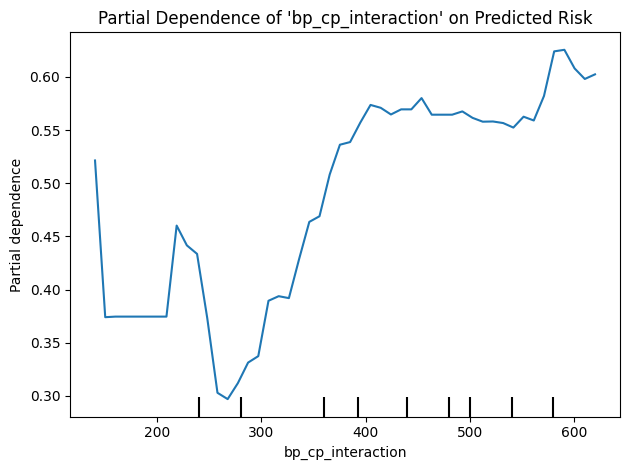

• The plot shows how changing 'bp_cp_interaction' alone (while keeping others fixed)
  affects the model's predicted risk of heart disease.
• higher curve, means higher values of the feature increase the risk.
• lower curve, means higher values reduce the risk.
/nShowing how the feature 'angina_cp_interaction' affects the prediction


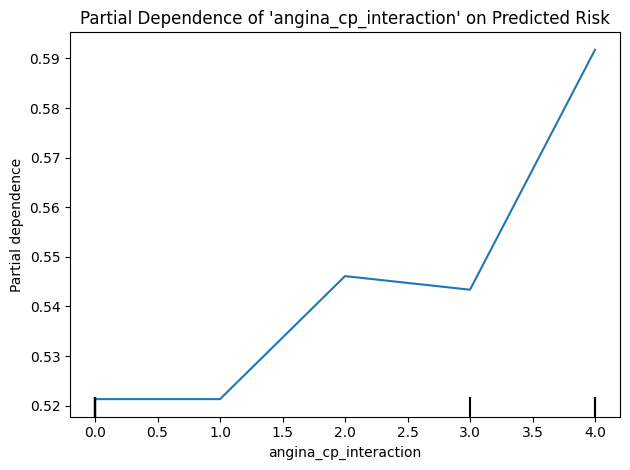

• The plot shows how changing 'angina_cp_interaction' alone (while keeping others fixed)
  affects the model's predicted risk of heart disease.
• higher curve, means higher values of the feature increase the risk.
• lower curve, means higher values reduce the risk.
/nShowing how the feature 'angina_hr_product' affects the prediction


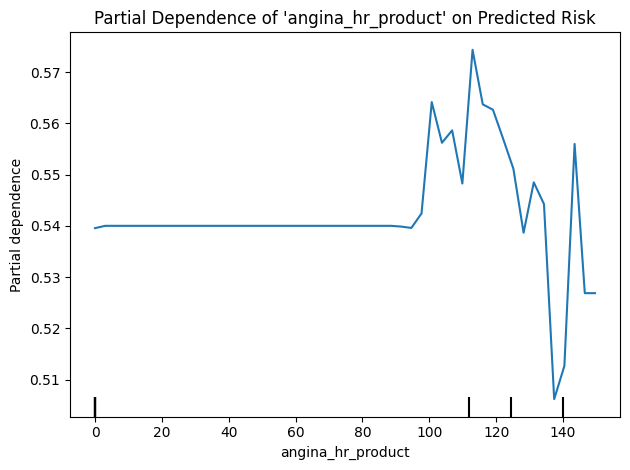

• The plot shows how changing 'angina_hr_product' alone (while keeping others fixed)
  affects the model's predicted risk of heart disease.
• higher curve, means higher values of the feature increase the risk.
• lower curve, means higher values reduce the risk.


In [22]:
from sklearn.inspection import PartialDependenceDisplay

# features with higher coorelation
features_to_explain = ['bp_cp_interaction', 'angina_cp_interaction', 'angina_hr_product']

print("\n--- PDP plot Explanation ---")

for feature in features_to_explain:
    print(f"/nShowing how the feature '{feature}' affects the prediction")

    # PDP
    disp = PartialDependenceDisplay.from_estimator(
        model,
        X_test,
        [feature],
        kind='average',
        grid_resolution=50
    )

    plt.title(f"Partial Dependence of '{feature}' on Predicted Risk")
    plt.tight_layout()
    plt.show()

    print(f"• The plot shows how changing '{feature}' alone (while keeping others fixed)")
    print("  affects the model's predicted risk of heart disease.")
    # to explain
    print("• higher curve, means higher values of the feature increase the risk.")
    print("• lower curve, means higher values reduce the risk.")


--- ICE Plot Explanation ---

Showing how the feature 'bp_cp_interaction' affects the prediction for individual patients


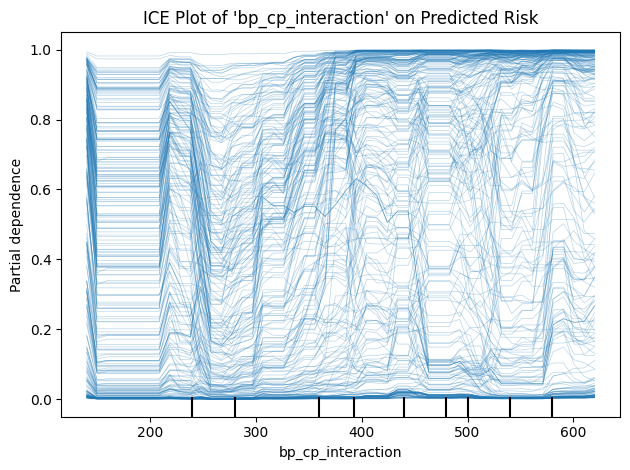

• Each line in the plot represents one patient's prediction trend as 'bp_cp_interaction' changes.
• If most lines slope upward, increasing 'bp_cp_interaction' increases predicted risk.
• If they slope downward, higher values reduce risk.
• Variability in slopes means the feature affects people differently.

Showing how the feature 'angina_cp_interaction' affects the prediction for individual patients


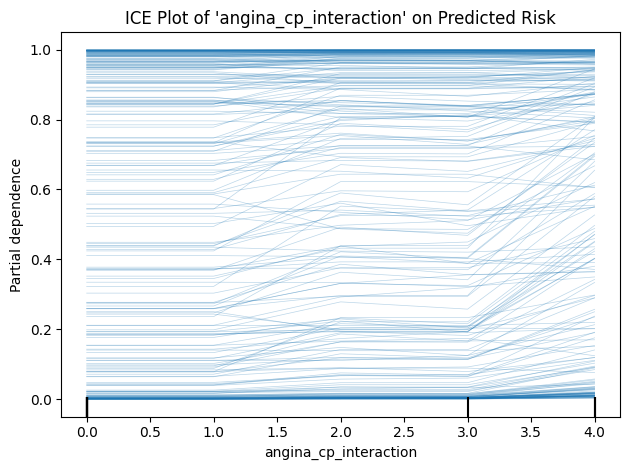

• Each line in the plot represents one patient's prediction trend as 'angina_cp_interaction' changes.
• If most lines slope upward, increasing 'angina_cp_interaction' increases predicted risk.
• If they slope downward, higher values reduce risk.
• Variability in slopes means the feature affects people differently.

Showing how the feature 'angina_hr_product' affects the prediction for individual patients


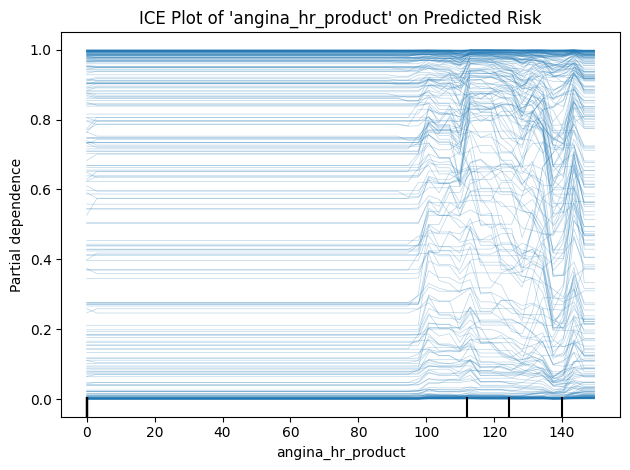

• Each line in the plot represents one patient's prediction trend as 'angina_hr_product' changes.
• If most lines slope upward, increasing 'angina_hr_product' increases predicted risk.
• If they slope downward, higher values reduce risk.
• Variability in slopes means the feature affects people differently.


In [23]:
# features with higher correlation
features_to_explain = ['bp_cp_interaction', 'angina_cp_interaction', 'angina_hr_product']

print("\n--- ICE Plot Explanation ---")

for feature in features_to_explain:
    print(f"\nShowing how the feature '{feature}' affects the prediction for individual patients")

    # ICE plot but individual instead
    disp = PartialDependenceDisplay.from_estimator(
        model,
        X_test,
        [feature],
        kind='individual',
        grid_resolution=50
    )

    plt.title(f"ICE Plot of '{feature}' on Predicted Risk")
    plt.tight_layout()
    plt.show()

    print(f"• Each line in the plot represents one patient's prediction trend as '{feature}' changes.")
    print(f"• If most lines slope upward, increasing '{feature}' increases predicted risk.")
    print(f"• If they slope downward, higher values reduce risk.")
    print(f"• Variability in slopes means the feature affects people differently.")